<a href="https://colab.research.google.com/github/yaser2532/python-basics-/blob/main/realworld_credit_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📥 Fetching real-world credit risk dataset from GitHub...
✅ Dataset successfully loaded! Shape: 32581 rows, 12 columns.

--- DATASET PREVIEW ---
   person_age  person_income  loan_amnt loan_intent  loan_status
0          22          59000      35000    PERSONAL            1
1          21           9600       1000   EDUCATION            0
2          25           9600       5500     MEDICAL            1
3          23          65500      35000     MEDICAL            1
4          24          54400      35000     MEDICAL            1

--- TARGET CLASS DISTRIBUTION ---
loan_status
Non-Default (0)    0.781836
Default (1)        0.218164
Name: proportion, dtype: float64
---------------------------------

🧼 Cleaning up data anomalies and outliers...
⚙️ Setting up automated preprocessing pipelines...
🤖 Instantiating and training Random Forest Classifier...
✅ Training complete!

📊 Evaluating model on validation data...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   su

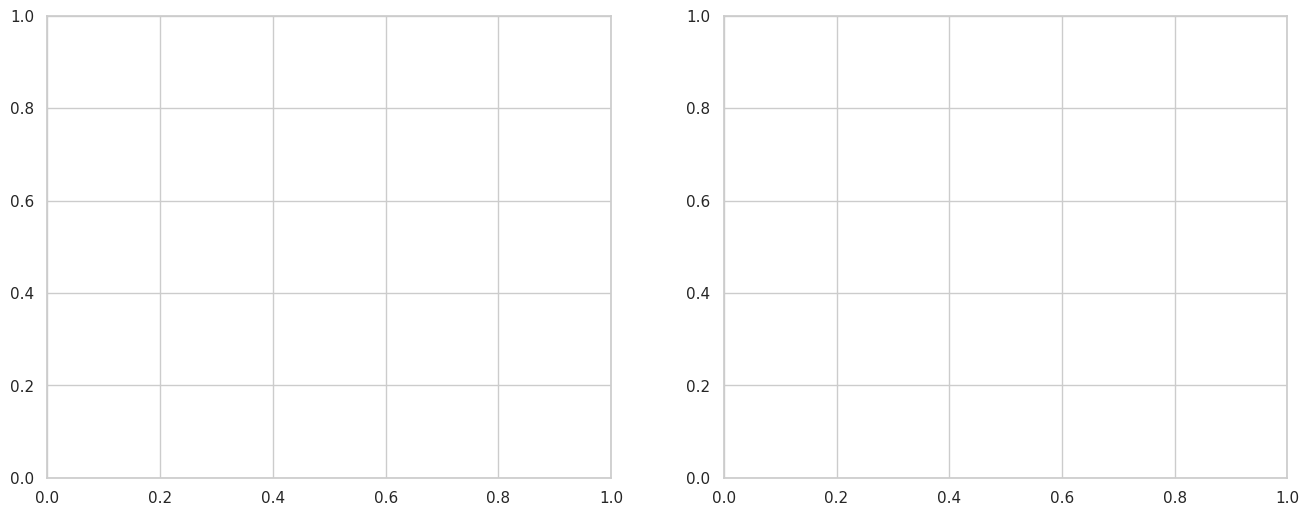

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Ensure plots look clean and modern
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


print("📥 Fetching real-world credit risk dataset from GitHub...")
url = "https://raw.githubusercontent.com/PhilChodrow/ml-notes/main/data/credit-risk/credit_risk_dataset.csv"

# Load data and handle memory efficiency
df = pd.read_csv(url)
print(f"✅ Dataset successfully loaded! Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

# Display a quick preview
print("--- DATASET PREVIEW ---")
print(df[['person_age', 'person_income', 'loan_amnt', 'loan_intent', 'loan_status']].head())
print("\n--- TARGET CLASS DISTRIBUTION ---")
print(df['loan_status'].value_counts(normalize=True).rename({0: 'Non-Default (0)', 1: 'Default (1)'}))
print("---------------------------------\n")

print("🧼 Cleaning up data anomalies and outliers...")
# Removing impossible structural anomalies (e.g., age > 100)
df = df[df['person_age'] <= 100]
# Removing unrealistically high employment durations
df = df[df['person_emp_length'] <= 60]


print("⚙️ Setting up automated preprocessing pipelines...")

# Define features and target variable
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Split data up-front to prevent data leakage during scaling/imputation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Segment numeric vs categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Transformation sub-pipeline for numeric data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handle missing income/interest rates
    ('scaler', StandardScaler())                  # Normalize scales
])

# Transformation sub-pipeline for categorical text data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))   # Convert to structural binary flags
])

# Combine individual processors into an overarching preprocessor block
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("🤖 Instantiating and training Random Forest Classifier...")

# Bundle preprocessing and model execution into a cohesive Pipeline object
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)
print("✅ Training complete!\n")

print("📊 Evaluating model on validation data...")
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Non-Default', 'Default']))


print("\n🎨 Rendering statistical performance visualizations...")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))


<Figure size 1000x600 with 0 Axes>


🔑 Top Factors Influencing Default Risk:


/tmp/ipykernel_4728/483368579.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


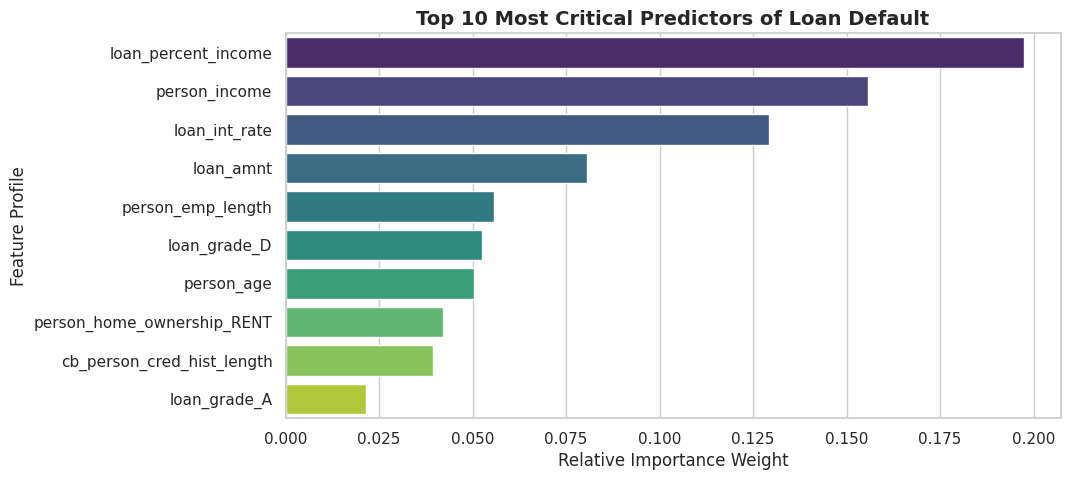

In [2]:
# Subplot A: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Good', 'Predicted Default'],
            yticklabels=['Actual Good', 'Actual Default'], ax=ax[0])
ax[0].set_title('Risk Matrix (Confusion Matrix)', fontsize=14, fontweight='bold')

# Subplot B: Receiver Operating Characteristic (ROC) Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (Type I Error)')
ax[1].set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax[1].set_title('ROC Curve Analysis', fontsize=14, fontweight='bold')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Extracting Feature Importance
print("\n🔑 Top Factors Influencing Default Risk:")
# Get feature names post-one-hot transformation
encoded_cat_features = model_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + encoded_cat_features

importances = model_pipeline.named_steps['classifier'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Render Feature Importance Graph
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Most Critical Predictors of Loan Default', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Weight')
plt.ylabel('Feature Profile')
plt.show()